# HBI tutorials — NB0: motivation & the estimand

**Audience.** A new collaborator who will *run* the catalog-HBI CDDF pipeline, and a
PI doing a math review. This notebook sets up *what we are measuring* and *why a
naive feed-forward count gets it wrong*. It runs in a few seconds and re-runs no
inference.

## The 5-notebook series

| NB | Title | What it does |
|----|-------|--------------|
| **00** | **motivation & the estimand** *(this one)* | Defines $f(N,X)$, $dN/dX$, $\Omega_\mathrm{DLA}$; shows *why* $\Omega$ is tail-dominated; previews the destination figure. |
| 01 | synthetic end-to-end | Injects a known CDDF into a toy catalog, forward-simulates detections, and recovers it — the whole machine in one runnable file. |
| 02 | forward kernel | Builds the per-object $(N,z)$ forward response (the GP posterior up-migration near the prior edge) that HBI inverts. |
| 03 | likelihood + MAP + band | The marked-Poisson likelihood, convex MAP, and the joint-MC credible band. |
| 04 | validation | Cross-mock transfer — the genuine external test (on-mock recovery is self-consistency, see the last cell). |

## The reduce-only discipline

These notebooks are **reduce-only**: GP inference is **never re-run** here. The
pipeline consumes a *frozen* detection catalog (the GP-DLA output) plus a frozen
completeness/purity matrix, and reduces them to a population statistic. Nothing in
this series touches `dla_gp.py` or re-runs Bayesian model selection. That keeps the
expensive, NERSC/GreatLakes-proven inference path byte-identical and makes every
tutorial cell cheap and deterministic.

> **What is *upstream* of this step.** Modelling choices like the mean-flux prior
> (Turner+2024 $\tau_0/\beta$) and continuum-fitting uncertainty affect *detection
> completeness* — whether a given absorber clears the GP evidence threshold. Those
> effects are baked into the **completeness matrix $C$** the GP run produced; they
> are an *input* to the reduction here, not something this notebook re-derives or
> re-tunes.

> **Data provenance.** Every printed number below comes from running real code or
> from a committed **MOCK** fixture (2LPT-0 injection, truth known). There are **no
> real-survey values** anywhere in this notebook.

In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
import sys
from pathlib import Path
_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
              if (p / "CDDF_analysis" / "hbi" / "cddf_catalog_hbi.py").exists()), None)
assert _root is not None, "repo root (CDDF_analysis/hbi/) not found"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
DATA = _root / "CDDF_analysis" / "hbi" / "tutorial_data"
import numpy as np
from CDDF_analysis.hbi import cddf_catalog_hbi as H
from CDDF_analysis import cddf_mock
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import json
print("env ready | numpy", np.__version__, "| fixtures:", DATA.is_dir())

env ready | numpy 2.4.4 | fixtures: True


**Import path note.** The canonical path is
`from CDDF_analysis.hbi import cddf_catalog_hbi as H`. The older
`CDDF_analysis.cddf_catalog_hbi` is a thin **back-compat shim** that re-exports the
same symbols — new code should import from `CDDF_analysis.hbi`.

## The estimand

The **column-density distribution function** (CDDF) $f(N, X)$ is the number of
absorbers per unit column density $N \equiv N_\mathrm{HI}$ (in $\mathrm{cm}^{-2}$)
per unit absorption distance $X$:

$$ f(N, X) \;=\; \frac{\partial^2 \mathcal{N}}{\partial N \,\partial X}. $$

We work on a fine $\log N$ grid of bins $b$ with heights $f_b$. Two integral
quantities are reported.

**Line density above a threshold** $N_\mathrm{thr}$:

$$ \frac{dN}{dX}(\ge N_\mathrm{thr}) \;=\; \sum_{b\,:\,N_b \ge N_\mathrm{thr}} f_b \,\Delta N_b. $$

**Neutral-gas mass density:**

$$ \Omega_\mathrm{DLA}(\ge N_\mathrm{thr}) \;=\; K \sum_{b\,:\,N_b \ge N_\mathrm{thr}} N_b \, f_b \,\Delta N_b,
   \qquad K = \frac{H_0\, m_\mathrm{H}}{c\,\rho_{c,0}} . $$

In **both** sums above, $\Delta N_b = 10^{\log N_{\mathrm{hi},b}} - 10^{\log N_{\mathrm{lo},b}}$
is the **linear** width in $N$ (see the gotcha box below) — the same $\Delta N_b$ enters
$dN/dX$ and $\Omega$; $\Omega$ merely carries the extra per-bin factor $N_b$.

### Gotcha: $\Delta N_b$ is a **linear** width

The bin width that multiplies $f_b$ is

$$ \Delta N_b \;=\; 10^{\log N_{\mathrm{hi},b}} - 10^{\log N_{\mathrm{lo},b}}, $$

a **linear** width in $N$, **not** $\Delta \log N$ and **not** $N\ln 10$. Because
the grid is uniform in $\log N$, $\Delta N_b$ grows by a factor $\sim 10$ per dex —
the high-$N$ bins are *enormously* wide in linear $N$.

### Consequence: $\Omega$ is tail-dominated

$dN/dX$ weights each bin by $f_b\,\Delta N_b$, but $\Omega$ weights by
$N_b\, f_b\,\Delta N_b$ — an *extra* factor of $N_b$. With $f(N)\propto N^{-\beta}$,
$\beta\!\sim\!1.5\text{–}2$ in the DLA bulk ($\log N \sim 20.3\text{–}21.0$), the
integrand $N f$ falls only slowly, so the highest-$N$ bins carry a large share of
$\Omega$. A small error in the *shape* of the high-$N$ tail barely moves $dN/dX$ but
can move $\Omega$ markedly. We demonstrate this mechanism numerically next.

> **On the slope $\beta$.** The CDDF *steepens* in the high-$N$ tail
> ($\log N \gtrsim 21$): the bulk slope is shallower ($\beta \approx 1.5\text{–}1.8$
> over $\log N$ 20.3–21.0) than the tail slope. The toy below deliberately uses a
> single steeper power law ($\beta \approx 2.5$, representative of the tail) for a
> clean, readable illustration — it is **not** a fit to any survey.

In [2]:
# Build a fine logN grid via the REAL estimator helper.
# A minimal HBIConfig (paths are dummies; we never load them here) — mirrors
# the _make_cfg(...) helper in tests/test_cddf_catalog_hbi.py, but restricted to a
# clean 20.0-22.0 DLA window so the toy power law is easy to read.
cfg = H.HBIConfig(
    catalog_dir="/dev/null", truth_path="/dev/null",
    bal_cat_path="/dev/null", molly_tsv="/dev/null", out_dir="/tmp",
    logN_lo=20.0, logN_hi=22.0, dlogN=0.1, drop_top_bin_above=21.9,
    zbins=(2.0, 2.5, 3.0, 3.5), report_logN_limits=(20.0, 20.3),
    H0=70.0, Omega_m=0.279,
)
logN_lo, logN_hi, N_b, dN_b = H.build_fine_grid(cfg)
print("fine grid: %d bins, logN in [%.2f, %.2f]" % (len(N_b), logN_lo[0], logN_hi[-1]))

# --- SELF-CHECK: dN_b is the LINEAR width 10^hi - 10^lo (gotcha 2) ---
expected = 10.0 ** logN_hi - 10.0 ** logN_lo
assert np.allclose(dN_b, expected, rtol=1e-12)
# and explicitly NOT the common N*ln10 mistake:
assert not np.allclose(dN_b, N_b * np.log(10.0), rtol=1e-3)
print("PASS: dN_b is linear (10^hi - 10^lo), not N*ln10")
print("  e.g. bin @ logN~%.2f: dN_b = %.3e cm^-2  (N_b*ln10 would be %.3e)"
      % (np.log10(N_b[-1]), dN_b[-1], N_b[-1] * np.log(10.0)))

# --- A toy power-law CDDF f_b = A * N_b^beta, anchored at logN = 20.3 ---
# beta = -2.5 is CHOSEN FOR ILLUSTRATION: it is representative of the DLA high-N
# TAIL (logN > 21, where the CDDF steepens above the break), and is steeper than
# the DLA-bulk slope (beta ~ 1.5-1.8 over logN 20.3-21.0). A single steep power law
# makes the tail-weight mechanism easy to read; it is NOT a fit to any survey. It is
# steep enough that the high-N bins carry few absorbers (small dN/dX share) but still
# a large share of Omega (extra N_b weight).
beta = -2.5
A = 1e-22 / (10 ** 20.3) ** beta          # height ~1e-22 cm^2 at N = 10^20.3
f_b = A * N_b ** beta

# dN/dX(>=20.3): sum over bins with N_b >= 10^20.3
sel = N_b >= 10 ** 20.3
dndx_303 = np.sum(f_b[sel] * dN_b[sel])
print("\ntoy power law beta=%.1f" % beta)
print("dN/dX(>=20.3) = %.4f   (ILLUSTRATIVE toy value, NOT matched to the measured" % dndx_303)
print("                        DESI/SDSS DLA abundance ~0.05-0.058; chosen for clarity)")
# Omega needs K -> computed with the real prefactor in cell 7; finish there.

fine grid: 19 bins, logN in [20.00, 21.90]
PASS: dN_b is linear (10^hi - 10^lo), not N*ln10
  e.g. bin @ logN~21.85: dN_b = 1.634e+21 cm^-2  (N_b*ln10 would be 1.630e+22)

toy power law beta=-2.5
dN/dX(>=20.3) = 0.0132   (ILLUSTRATIVE toy value, NOT matched to the measured
                        DESI/SDSS DLA abundance ~0.05-0.058; chosen for clarity)


### Figure: the toy $f(N)$ on the fine grid

Before any integral, *look* at the CDDF we just built. On a log--log axis a power
law $f \propto N^{\beta}$ is a straight line of slope $\beta$. The steepness
(here $\beta=-2.5$) is the whole story: it means there are vastly fewer absorbers
per unit $\log N$ at high $N$ than at low $N$. Keep this picture in mind — it is
what makes $dN/dX$ tail-*insensitive* while $\Omega$ is tail-*dominated* (next).

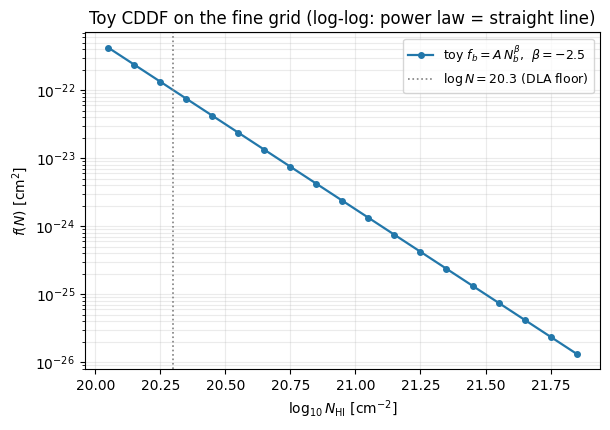

slope check: d log10(f) / d logN = -2.500  (= beta = -2.5)


In [3]:
# Plot the toy CDDF on the fine grid. Log-log: a power law is a straight line.
logN_ctr = np.log10(N_b)
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(logN_ctr, f_b, "o-", color="#27a", ms=4, lw=1.6,
        label=r"toy $f_b = A\,N_b^{\beta}$,  $\beta=%.1f$" % beta)
ax.axvline(20.3, ls=":", color="gray", lw=1.2, label=r"$\log N = 20.3$ (DLA floor)")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10} N_\mathrm{HI}\ \mathrm{[cm^{-2}]}$")
ax.set_ylabel(r"$f(N)\ \mathrm{[cm^{2}]}$")
ax.set_title("Toy CDDF on the fine grid (log-log: power law = straight line)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()
print("slope check: d log10(f) / d logN = %.3f  (= beta = %.1f)"
      % (np.polyfit(logN_ctr, np.log10(f_b), 1)[0], beta))

In [4]:
# Perturb the toy CDDF the way the raw feed-forward error does: a too-flat high-N
# tail = the heights above logN = 21.0 are over-stated. Here a MODEST 30% boost of
# the tail heights (a realistic magnitude for posterior up-migration near the prior
# edge -- it makes the steep tail shallower).
boost = 1.30
flat_above = 21.0
f_b_pert = f_b.copy()
tail = np.log10(N_b) > flat_above
f_b_pert[tail] = f_b[tail] * boost

# dN/dX is insensitive to the tail (those bins carry few absorbers despite being
# linearly wide -- the steep f_b wins):
dndx_orig = np.sum(f_b[sel]      * dN_b[sel])
dndx_pert = np.sum(f_b_pert[sel] * dN_b[sel])
print("dN/dX(>=20.3):  original %.4f  ->  tail-boosted %.4f   (%+.1f%%)"
      % (dndx_orig, dndx_pert, 100 * (dndx_pert / dndx_orig - 1)))

# Omega weights by an EXTRA factor of N_b, so the same tail boost matters far more.
# Finish the numbers (and narration) once K is in hand in cell 7 -- carry the
# integrands (Omega/K) so we can scale by the real K there:
omega_integrand_orig = np.sum(N_b[sel] * f_b[sel]      * dN_b[sel])  # = Omega/K
omega_integrand_pert = np.sum(N_b[sel] * f_b_pert[sel] * dN_b[sel])
print("Omega integrand (Omega/K):  original %.3e  ->  tail-boosted %.3e   (%+.1f%%)"
      % (omega_integrand_orig, omega_integrand_pert,
         100 * (omega_integrand_pert / omega_integrand_orig - 1)))
print("\n--> The SAME 30%% tail boost moves dN/dX by only a few %%, but Omega by ~4x")
print("    more (here dN/dX +2.6%% vs Omega +10.3%%). The extra N_b weight makes a")
print("    too-flat high-N tail OVER-STATE Omega -- this is the mechanism behind the")
print("    raw feed-forward Omega over-statement.")

dN/dX(>=20.3):  original 0.0132  ->  tail-boosted 0.0136   (+2.6%)
Omega integrand (Omega/K):  original 6.711e+18  ->  tail-boosted 7.401e+18   (+10.3%)

--> The SAME 30%% tail boost moves dN/dX by only a few %%, but Omega by ~4x
    more (here dN/dX +2.6%% vs Omega +10.3%%). The extra N_b weight makes a
    too-flat high-N tail OVER-STATE Omega -- this is the mechanism behind the
    raw feed-forward Omega over-statement.


### Figure: $dN/dX$ vs $\Omega$ integrand weighting

The two reported integrals weight the *same* CDDF differently. $dN/dX$ sums
$f_b\,\Delta N_b$; $\Omega$ sums $N_b\,f_b\,\Delta N_b$ — an **extra factor of
$N_b$** per bin. Below, left is the $dN/dX$ integrand $f_b\,\Delta N_b$ (the
per-bin contribution to the line density), right is the $\Omega$ integrand
$N_b\,f_b\,\Delta N_b$ (the per-bin contribution to the mass density). The
$\ge 20.3$ region is shaded. Watch the mass migrate: the extra $N_b$ weight
drags the $\Omega$ integrand to *high* $N$ even though the CDDF itself is steeply
falling. That is *why* a small high-$N$ tail-shape error barely touches $dN/dX$
but moves $\Omega$.

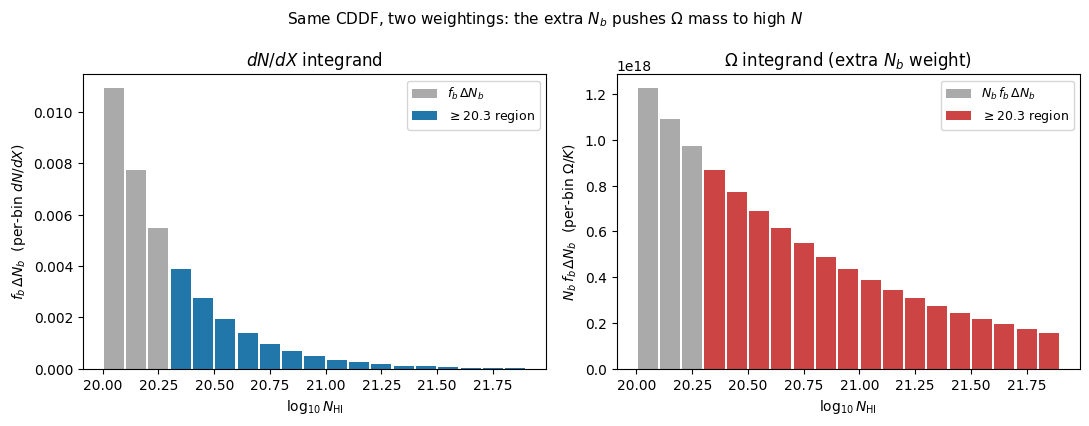

fraction of the (>=20.3) integral that sits at logN >= 21.0:
  dN/dX : 8.5%   <- tail carries little of the line density
  Omega : 34.2%   <- tail carries a much larger share of the mass


In [5]:
# Per-bin integrands. dN/dX weights f_b*dN_b; Omega weights N_b*f_b*dN_b.
w_dndx  = f_b * dN_b                 # per-bin contribution to dN/dX
w_omega = N_b * f_b * dN_b           # per-bin contribution to Omega/K
logN_ctr = np.log10(N_b)
hi = logN_ctr >= 20.3

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharex=True)

ax = axes[0]
ax.bar(logN_ctr, w_dndx, width=0.09, color="#aaa", label=r"$f_b\,\Delta N_b$")
ax.bar(logN_ctr[hi], w_dndx[hi], width=0.09, color="#27a",
       label=r"$\geq 20.3$ region")
ax.set_xlabel(r"$\log_{10} N_\mathrm{HI}$")
ax.set_ylabel(r"$f_b\,\Delta N_b$  (per-bin $dN/dX$)")
ax.set_title(r"$dN/dX$ integrand")
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(logN_ctr, w_omega, width=0.09, color="#aaa",
       label=r"$N_b\,f_b\,\Delta N_b$")
ax.bar(logN_ctr[hi], w_omega[hi], width=0.09, color="#c44",
       label=r"$\geq 20.3$ region")
ax.set_xlabel(r"$\log_{10} N_\mathrm{HI}$")
ax.set_ylabel(r"$N_b\,f_b\,\Delta N_b$  (per-bin $\Omega/K$)")
ax.set_title(r"$\Omega$ integrand (extra $N_b$ weight)")
ax.legend(fontsize=9)

fig.suptitle("Same CDDF, two weightings: the extra $N_b$ pushes $\\Omega$ mass to high $N$",
             fontsize=11)
fig.tight_layout()
plt.show()

# Where does each integral concentrate? Report the high-N share each puts >= 21.0.
above21 = logN_ctr >= 21.0
share_dndx  = w_dndx[above21].sum()  / w_dndx[hi].sum()
share_omega = w_omega[above21].sum() / w_omega[hi].sum()
print("fraction of the (>=20.3) integral that sits at logN >= 21.0:")
print("  dN/dX : %.1f%%   <- tail carries little of the line density" % (100*share_dndx))
print("  Omega : %.1f%%   <- tail carries a much larger share of the mass"
      % (100*share_omega))

<details>
<summary><b>The mass-density prefactor</b> $K$ (click to expand the math)</summary>

The neutral-gas mass density follows from converting a column-density integral into
a mean comoving mass density divided by the critical density:

$$ K = \frac{H_0\, m_\mathrm{H}}{c\,\rho_{c,0}}, \qquad
   \rho_{c,0} = \frac{3 H_0^2}{8\pi G}. $$

Substituting $\rho_{c,0}$,

$$ K = \frac{H_0\, m_\mathrm{H}}{c}\cdot\frac{8\pi G}{3 H_0^2}
     = \frac{8\pi G\, m_\mathrm{H}}{3\,c\,H_0}. $$

**Units (be careful here).** In CGS, $K = H_0\, m_\mathrm{H}/(c\,\rho_{c,0})$ carries
units of $\mathrm{cm}^{2}$, and the integrand $N\,f(N)\,dN$ (with $N$ in
$\mathrm{cm}^{-2}$, $f(N)$ in $\mathrm{cm}^{2}$, $dN$ in $\mathrm{cm}^{-2}$) carries
units of $\mathrm{cm}^{-2}$. Only their **product** $\Omega_\mathrm{DLA} = K \sum N f\,\Delta N$
is **dimensionless** — neither factor is dimensionless on its own. For
$H_0 = 70\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$, $K \approx 1.38\times10^{-23}\ \mathrm{cm}^{2}$.

- **$h$-scaling:** $K \propto 1/H_0$, so $\Omega_\mathrm{DLA}\propto h^{-1}$. Always
  state the assumed $H_0$ alongside an $\Omega$.
- **Mass convention:** using the H-atom mass $m_\mathrm{H}$ gives the *neutral-hydrogen-only*
  $\Omega_\mathrm{HI}$ (Noterdaeme+2012 / Crighton+2015). For total neutral *gas*
  including helium ($\Omega_\mathrm{DLA}$), multiply by $\mu = 1/X_\mathrm{H}\approx1.3$.

</details>

In [6]:
# Call the REAL prefactor (from cddf_mock, re-exported on H). Signature:
#   omega_hi_prefactor(H0_km_s_Mpc=70.0) -> dimensionless K
K = H.omega_hi_prefactor(70.0)
print("K = %.6e  cm^2  (Omega = K * sum N f dN is dimensionless; K alone is not)" % K)

# --- SELF-CHECK: K matches the corrected value 1.376e-23 (NOT ~2.8e-28) ---
assert abs(K - 1.376e-23) < 1e-2 * 1.376e-23
print("PASS: K within 1%% of 1.376e-23")

# Now finish the Omega numbers from cells 4-5 with the real K.
omega_303      = K * omega_integrand_orig   # toy power-law Omega(>=20.3)
omega_303_pert = K * omega_integrand_pert   # tail-boosted Omega(>=20.3)
print("\ntoy power law, Omega(>=20.3):")
print("  original     Omega = %.3e" % omega_303)
print("  tail-boosted Omega = %.3e   (%+.1f%%)"
      % (omega_303_pert, 100 * (omega_303_pert / omega_303 - 1)))
print("\nThe same tail boost barely moved dN/dX but moved Omega ~4x more ->")
print("dN/dX and Omega respond DIFFERENTLY to a high-N tail-shape error, exactly")
print("because Omega carries the extra N_b weight.")

K = 1.375931e-23  cm^2  (Omega = K * sum N f dN is dimensionless; K alone is not)
PASS: K within 1%% of 1.376e-23

toy power law, Omega(>=20.3):
  original     Omega = 9.234e-05
  tail-boosted Omega = 1.018e-04   (+10.3%)

The same tail boost barely moved dN/dX but moved Omega ~4x more ->
dN/dX and Omega respond DIFFERENTLY to a high-N tail-shape error, exactly
because Omega carries the extra N_b weight.


### Figure: the tail-boost, and its asymmetric effect on $dN/dX$ vs $\Omega$

Now *see* the perturbation from cells 5/7. Left: the original toy CDDF (black) and
the **tail-boosted** version (red) — the only change is a $30\%$ lift of the
heights above $\log N = 21.0$ (the highlighted band), the kind of too-flat tail a
raw feed-forward count produces. Right: the resulting change in the two integrals.
The same tail boost is nearly invisible to $dN/dX$ but clearly moves $\Omega$ —
the figure is the picture behind the printed percentages above.

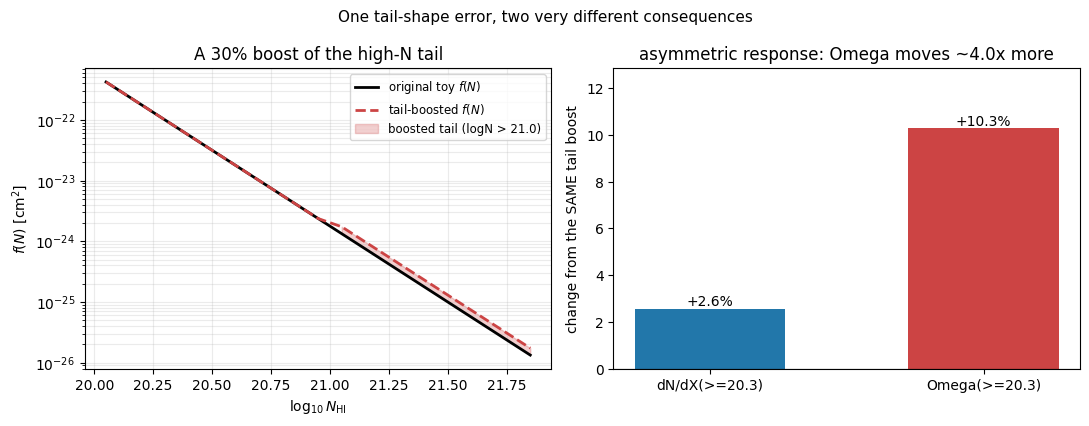

In [7]:
# Before/after CDDF + the asymmetric integral response, as one figure.
logN_ctr = np.log10(N_b)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# Left: original vs tail-boosted f(N), highlight the boosted band
axL.plot(logN_ctr, f_b, "k-", lw=2.0, label="original toy $f(N)$")
axL.plot(logN_ctr, f_b_pert, "--", color="#c44", lw=2.0, label="tail-boosted $f(N)$")
band = np.log10(N_b) > flat_above
axL.fill_between(logN_ctr, f_b, f_b_pert, where=band, color="#c44", alpha=0.25,
                 label="boosted tail (logN > %.1f)" % flat_above)
axL.set_yscale("log")
axL.set_xlabel(r"$\log_{10} N_\mathrm{HI}$"); axL.set_ylabel(r"$f(N)\ \mathrm{[cm^{2}]}$")
axL.set_title("A %d%% boost of the high-N tail" % int(round(100*(boost-1))))
axL.legend(fontsize=8.5, loc="upper right")
axL.grid(True, which="both", alpha=0.25)

# Right: the percent change each integral suffers (bar pair)
d_dndx  = 100 * (dndx_pert / dndx_orig - 1)
d_omega = 100 * (omega_303_pert / omega_303 - 1)
bars = axR.bar(["dN/dX(>=20.3)", "Omega(>=20.3)"], [d_dndx, d_omega],
               color=["#27a", "#c44"], width=0.55)
for rect, val in zip(bars, [d_dndx, d_omega]):
    axR.annotate("%+.1f%%" % val, (rect.get_x() + rect.get_width()/2, val),
                 ha="center", va="bottom", fontsize=10)
axR.axhline(0, color="k", lw=0.8)
axR.set_ylabel("change from the SAME tail boost")
axR.set_title("asymmetric response: Omega moves ~%.1fx more" % (d_omega / d_dndx))
axR.set_ylim(0, max(d_dndx, d_omega) * 1.25)

fig.suptitle("One tail-shape error, two very different consequences", fontsize=11)
fig.tight_layout()
plt.show()

PASS: raw-FF Omega R0 = 1.468 (>1.2);  HBI_purity_mixture dN/dX R0 = 1.090 (in [1.0,1.2])


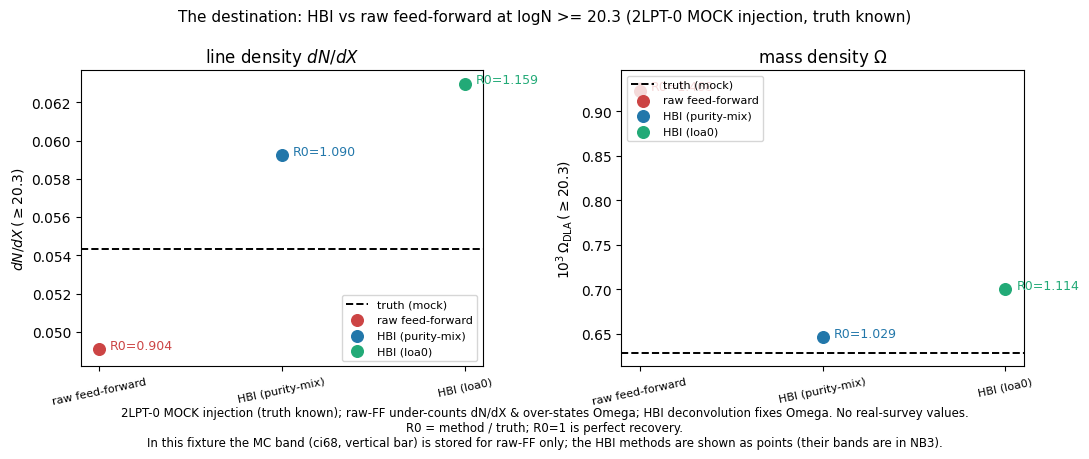

In [8]:
# Load the committed MOCK fixture (2LPT-0 injection; truth known).
d = json.load(open(DATA / "compare_synthesis.json"))
truth = d["table"]["truth"]
m = d["table"]["methods"]

# --- SELF-CHECK: the fixture reproduces the known qualitative behaviour ---
assert m["raw_feedforward"]["omega"]["20.3"]["R0"] > 1.2          # raw-FF over-states Omega
assert 1.0 <= m["HBI_purity_mixture"]["dndx"]["20.3"]["R0"] <= 1.2  # HBI brings dN/dX into band
print("PASS: raw-FF Omega R0 = %.3f (>1.2);  HBI_purity_mixture dN/dX R0 = %.3f (in [1.0,1.2])"
      % (m["raw_feedforward"]["omega"]["20.3"]["R0"],
         m["HBI_purity_mixture"]["dndx"]["20.3"]["R0"]))

thr = "20.3"
methods = ["raw_feedforward", "HBI_purity_mixture", "HBI_loa0"]
labels  = ["raw feed-forward", "HBI (purity-mix)", "HBI (loa0)"]
colors  = ["#c44", "#27a", "#2a7"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel A: dN/dX(>=20.3)
ax = axes[0]
ax.axhline(truth["dndx"][thr], color="k", ls="--", lw=1.4, label="truth (mock)")
for j, (key, lab, c) in enumerate(zip(methods, labels, colors)):
    rec = m[key]["dndx"][thr]
    ax.scatter([j], [rec["value"]], s=70, color=c, zorder=3, label=lab)
    if "ci68" in rec:
        lo, hi = rec["ci68"]
        ax.plot([j, j], [lo, hi], color=c, lw=2.5, zorder=2)
    ax.annotate("R0=%.3f" % rec["R0"], (j, rec["value"]),
                textcoords="offset points", xytext=(8, 0), fontsize=9, color=c)
ax.set_xticks(range(len(methods))); ax.set_xticklabels(labels, rotation=12, fontsize=8)
ax.set_ylabel(r"$dN/dX\,(\geq 20.3)$"); ax.set_title(r"line density $dN/dX$")
ax.legend(fontsize=8, loc="lower right")

# Panel B: 10^3 * Omega(>=20.3)
ax = axes[1]
ax.axhline(1e3 * truth["omega"][thr], color="k", ls="--", lw=1.4, label="truth (mock)")
for j, (key, lab, c) in enumerate(zip(methods, labels, colors)):
    rec = m[key]["omega"][thr]
    ax.scatter([j], [1e3 * rec["value"]], s=70, color=c, zorder=3, label=lab)
    if "ci68" in rec:
        lo, hi = rec["ci68"]
        ax.plot([j, j], [1e3 * lo, 1e3 * hi], color=c, lw=2.5, zorder=2)
    ax.annotate("R0=%.3f" % rec["R0"], (j, 1e3 * rec["value"]),
                textcoords="offset points", xytext=(8, 0), fontsize=9, color=c)
ax.set_xticks(range(len(methods))); ax.set_xticklabels(labels, rotation=12, fontsize=8)
ax.set_ylabel(r"$10^3\,\Omega_\mathrm{DLA}\,(\geq 20.3)$"); ax.set_title(r"mass density $\Omega$")
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("The destination: HBI vs raw feed-forward at logN >= 20.3 "
             "(2LPT-0 MOCK injection, truth known)", fontsize=11)
fig.text(0.5, -0.06,
         "2LPT-0 MOCK injection (truth known); raw-FF under-counts dN/dX & over-states "
         "Omega; HBI deconvolution fixes Omega. No real-survey values.\n"
         "R0 = method / truth; R0=1 is perfect recovery.\n"
         "In this fixture the MC band (ci68, vertical bar) is stored for raw-FF only; "
         "the HBI methods are shown as points (their bands are in NB3).",
         ha="center", fontsize=8.5)
fig.tight_layout()
plt.show()

## What the next notebooks do

The figure above is the **destination** — the machine the rest of the series builds.
Two things to take away:

- **Raw feed-forward** fails in **two causally distinct ways** — do not conflate them:
  - The $dN/dX$ **deficit** is pure **incompleteness**: systems below the SNR /
    detectability threshold are missed *entirely* ($C<1$), so the count is simply
    too low. This is a counting loss, fixed by undoing the selection.
  - The $\Omega$ **over-statement** is a *different* mechanism — **prior-edge
    Eddington up-migration**. The systems that *are* kept have their measured
    $\hat N$ biased *upward* near the sharp $\log N \approx 20.3$ prior edge,
    flattening the high-$N$ tail. Nothing is miscounted; the *shape* of the kept
    detections is distorted, and the extra $N_b$ weight in $\Omega$ (cells 5/7)
    amplifies that shape error into a large mass-density bias.

  So incompleteness lowers $dN/dX$ while up-migration of *kept* detections raises
  $\Omega$ — two separate effects that happen to coexist in the raw count.
- **HBI** builds the per-object $(N,z)$ *forward response* and **inverts** it
  (deconvolution), bringing both $dN/dX$ and $\Omega$ back into agreement with the
  injected mock truth.

**NB1** builds and inverts that forward response on **synthetic** data you can run in
seconds — no GP, no catalog I/O — so you can see the whole inversion end-to-end
before meeting the real kernel (NB2) and likelihood (NB3).

> **Honesty.** The on-mock recovery shown here is a **self-consistency** check: the
> completeness correction is calibrated on the *same* mock, so the recovery factor
> $\alpha = 1/R_0$ is a tautology on that mock. The genuine **external** test is
> **cross-mock transfer** — calibrate on one mock, validate on a held-out mock built
> with a different recipe — which is the subject of **NB4**.